In [ ]:
import copy
import h5py
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

from utility import *
from models_arch import *

# Stage 4: Evaluation and FLOPs-Accuracy Analysis

## Overview
This notebook analyzes the trained sparse classifier and compares computational efficiency (FLOPs) vs accuracy.

**Objectives**:
1. Evaluate sparse classifier on test set
2. Compute FLOPs (floating-point operations) for sparse network
3. Apply structured pruning at various ratios
4. Plot FLOPs vs accuracy tradeoff
5. Compare with dense baseline CNN

**Why FLOPs Analysis?**
- Standard ML metrics (parameters, MACs) don't capture sparse efficiency
- Sparse convolution: actual FLOPs depend on active coordinates
- Need custom FLOPs counter that understands rulebook-based computation
- Pruning reduces non-zero weights → further reduces FLOPs

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LABELLED_H5 = "data/Dataset_Specific_labelled.h5"
AE1_CKPT = "ae1_trained.pth"
AE2_CKPT = "ae2_trained.pth"
CLS_CKPT = "best_sparse_classifier.pth"

In [ ]:
full_dataset = H5LabelledDataset(LABELLED_H5)

n_total = len(full_dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=labelled_sparse_collate,
    num_workers=0
)

In [ ]:
ae1 = AutoEncoder1().to(device)
ae1.load_state_dict(torch.load(AE1_CKPT, map_location=device))
ae1.eval()

ae2 = AutoEncoder2().to(device)
ae2.load_state_dict(torch.load(AE2_CKPT, map_location=device))
ae2.eval()

model = SparseEventClassifier(ae1.encoder, ae2.encoder).to(device)

ckpt = torch.load(CLS_CKPT, map_location=device)
if "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)

model.eval()

/tmp/ipykernel_6226/3758876769.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ae1.load_state_dict(torch.load(AE1_CKPT, map_location=device))
/tmp/ipykernel_6226/3758876

SparseEventClassifier(
  (encoder1): Encoder1(
    (stage1): SparseVGGStage(
      (blocks): ModuleList(
        (0-2): 3 x SparseVSCBlockRulebook(
          (vsc): VSC3x3Rulebook()
          (bn): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
        )
      )
      (pool): SparseMaxPool2x2()
    )
    (stage2): SparseVGGStage(
      (blocks): ModuleList(
        (0-1): 2 x SparseVSCBlockRulebook(
          (vsc): VSC3x3Rulebook()
          (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
        )
      )
      (pool): SparseMaxPool2x2()
    )
  )
  (encoder2): Encoder2(
    (stage): SparseVGGStage(
      (blocks): ModuleList(
        (0-2): 3 x SparseVSCBlockRulebook(
          (vsc): VSC3x3Rulebook()
          (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
        )
      )
      (pool): SparseMaxPool2x

## Part 1: FLOPs Computation for Sparse Networks

**Key Challenge**: Standard FLOP counters don't work!
- PyTorch profilers assume dense operations
- Sparse convolution FLOPs depend on *actual* active coordinates at runtime
- Cannot be computed statically without forward pass

**Custom FLOPs Calculation**:
For sparse convolution at offset k:
```
FLOPs_k = 2 × |in_rows| × C_in × C_out × density
```
where:
- `|in_rows|` = number of valid input-output pairs in rulebook
- `C_in, C_out` = input/output channels
- `density` = sparsity of learned weights (fraction non-zero)

**Total FLOPs includes**:
- All sparse convolutions (per stage, per offset)
- Batch normalization + ReLU (3 * active_sites * channels)
- Global pooling (aggregation and division)
- Linear layers in classifier head

**Efficiency Metric**:
```
FLOPs/sample = total_FLOPs / batch_size
```
Measures computational cost per prediction

In [ ]:
class SparseFlopCounter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.flops = 0.0

    def add_sparse_conv(self, rules, cin, cout, density=1.0):
        for in_rows, _ in rules:
            pairs = in_rows.numel()
            self.flops += 2.0 * pairs * cin * cout * density

    def add_bn_relu(self, n_sites, channels):
        self.flops += 3.0 * n_sites * channels

    def add_global_pool(self, n_sites, channels, batch_size):
        self.flops += n_sites * channels + batch_size * channels

    def add_linear(self, batch_size, cin, cout, density=1.0):
        self.flops += 2.0 * batch_size * cin * cout * density

    def get(self):
        return float(self.flops)

In [ ]:
def tensor_density(t):
    total = t.numel()
    nonzero = (t != 0).sum().item()
    return nonzero / total if total > 0 else 1.0

In [ ]:
def run_stage_with_flops(stage, coords, feats, cin, cout, flop_counter):
    rules = build_vsc_rulebook(coords)

    for block in stage.blocks:
        d = tensor_density(block.vsc.weight)
        flop_counter.add_sparse_conv(rules, cin, cout, density=d)

        feats = block(coords, feats, rules)[1]   # block returns coords_out, feats_out
        flop_counter.add_bn_relu(feats.size(0), cout)

        cin = cout

    coords, feats = stage.pool(coords, feats)
    return coords, feats

In [ ]:
def forward_with_flops(model, coords, feats, flop_counter):
    batch_size = int(coords[:, 0].max().item()) + 1

    # Encoder1 stage1: 8 -> 16, 3 blocks
    coords, feats = run_stage_with_flops(
        model.encoder1.stage1, coords, feats, cin=8, cout=16, flop_counter=flop_counter
    )

    # Encoder1 stage2: 16 -> 32, 2 blocks
    coords, feats = run_stage_with_flops(
        model.encoder1.stage2, coords, feats, cin=16, cout=32, flop_counter=flop_counter
    )

    # Encoder2 stage: 32 -> 64, 3 blocks
    coords, feats = run_stage_with_flops(
        model.encoder2.stage, coords, feats, cin=32, cout=64, flop_counter=flop_counter
    )

    # Global mean pool
    z = sparse_global_mean_pool(coords, feats, batch_size)
    flop_counter.add_global_pool(feats.size(0), feats.size(1), batch_size)

    # Classifier head
    head0 = model.head[0]   # Linear(64,64)
    head3 = model.head[3]   # Linear(64,2)

    flop_counter.add_linear(batch_size, 64, 64, density=tensor_density(head0.weight))
    flop_counter.flops += batch_size * 64   # ReLU
    flop_counter.add_linear(batch_size, 64, 2, density=tensor_density(head3.weight))

    logits = model.head(z)
    return logits

In [ ]:
@torch.no_grad()
def evaluate_with_flops(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_flops = 0.0

    flop_counter = SparseFlopCounter()

    for batch in loader:
        coords = batch["coords"].to(device)
        feats = batch["feats"].to(device)
        labels = batch["labels"].to(device)

        flop_counter.reset()
        logits = forward_with_flops(model, coords, feats, flop_counter)

        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)

        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_correct += (preds == labels).sum().item()
        total_samples += bs
        total_flops += flop_counter.get()

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    err = 1.0 - acc
    avg_flops_per_sample = total_flops / total_samples

    return avg_loss, acc, err, avg_flops_per_sample

In [ ]:
def apply_global_pruning(model, amount):
    parameters_to_prune = []

    for block in model.encoder1.stage1.blocks:
        parameters_to_prune.append((block.vsc, "weight"))

    for block in model.encoder1.stage2.blocks:
        parameters_to_prune.append((block.vsc, "weight"))

    for block in model.encoder2.stage.blocks:
        parameters_to_prune.append((block.vsc, "weight"))

    parameters_to_prune.append((model.head[0], "weight"))
    parameters_to_prune.append((model.head[3], "weight"))

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount
    )

    for module, name in parameters_to_prune:
        prune.remove(module, name)

In [ ]:
criterion = nn.CrossEntropyLoss()

pruning_ratios = [0.0, 0.2, 0.4, 0.6, 0.8]
flops_list = []
err_list = []
acc_list = []

for ratio in pruning_ratios:
    pruned_model = copy.deepcopy(model).to(device)

    if ratio > 0:
        apply_global_pruning(pruned_model, amount=ratio)

    loss, acc, err, flops = evaluate_with_flops(
        pruned_model, test_loader, criterion, device
    )

    flops_list.append(flops)
    err_list.append(err)
    acc_list.append(acc)

    print(
        f"Pruning ratio: {ratio:.1f} | "
        f"Acc: {acc:.4f} | Err: {err:.4f} | FLOPs/sample: {flops:.2f}"
    )

Pruning ratio: 0.0 | Acc: 0.8033 | Err: 0.1967 | FLOPs/sample: 61660401.92
Pruning ratio: 0.2 | Acc: 0.8027 | Err: 0.1973 | FLOPs/sample: 50264834.89
Pruning ratio: 0.4 | Acc: 0.7633 | Err: 0.2367 | FLOPs/sample: 38853365.18
Pruning ratio: 0.6 | Acc: 0.7367 | Err: 0.2633 | FLOPs/sample: 27357519.87
Pruning ratio: 0.8 | Acc: 0.5240 | Err: 0.4760 | FLOPs/sample: 15207121.28


## Part 2: Pruning and FLOPs-Error Tradeoff

**Pruning Strategy**:
Global L1-unstructured pruning applied to all weight matrices:
- Sparse convolution weights (all stages)
- Classifier head linear layers

**Process**:
```
For each pruning ratio (0%, 20%, 40%, 60%, 80%):
    1. Deep copy model
    2. Apply global L1 pruning at specified ratio
    3. Evaluate on test set
    4. Compute FLOPs using custom counter
    5. Record accuracy and FLOPs
```

**Why Pruning?**
- Further reduces non-zero weights
- Decreases density parameter in FLOP computation
- Creates accuracy-efficiency tradeoff
- Shows how sparse networks degrade gracefully

**Expected Results**:
- 0% pruning: Maximum accuracy, maximum FLOPs
- Increasing pruning: Lower error plateau → rapid dropped accuracy at high ratios
- Sparse system: Better FLOPs-accuracy tradeoff than dense baseline

**Evaluation Metrics**:
- **FLOPs/sample**: Floating-point operations per inference
- **Error rate**: 1 - accuracy
- **Pareto analysis**: Find operating points on efficiency frontier

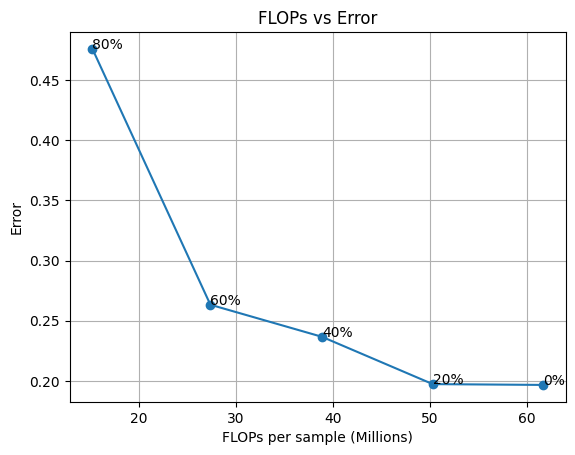

In [ ]:
flops_m = [f/1e6 for f in flops_list]

plt.plot(flops_m, err_list, marker="o")

for x,y,r in zip(flops_m, err_list, pruning_ratios):
    plt.annotate(f"{int(r*100)}%", (x,y))

plt.xlabel("FLOPs per sample (Millions)")
plt.ylabel("Error")
plt.title("FLOPs vs Error")
plt.grid(True)
plt.show()

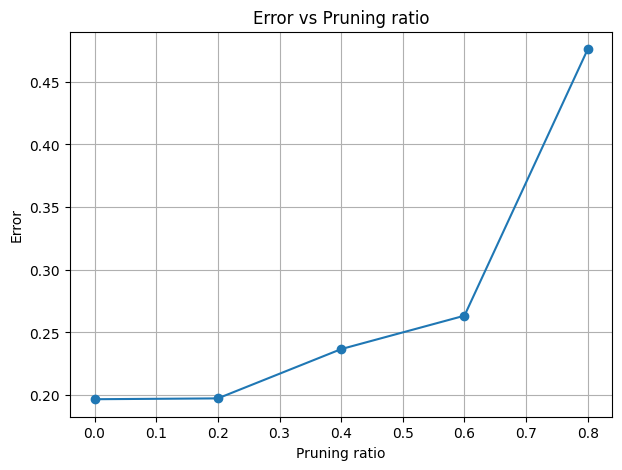

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(pruning_ratios, err_list, marker="o")
plt.xlabel("Pruning ratio")
plt.ylabel("Error")
plt.title("Error vs Pruning ratio")
plt.grid(True)
plt.show()